# Notebook 5: Inventory Optimization
## Retail Demand Forecasting — Store Sales (Favorita)
 
---
 
**Objective**
 
Translate the demand forecasts and forecast-error estimates from NB2–NB4
into concrete, executable inventory policy: Safety Stock, Reorder Point
(ROP), and Economic Order Quantity (EOQ).
 
**Logical chain**
 
```
Forecast (μ, σ) from NB4  →  Safety Stock  →  Reorder Point  →  EOQ
```
 
**Design decisions carried over from NB4**
 
- **σ (forecast error) is taken from the rolling-origin CV results**
  (`nb4_rolling_cv_results.csv`), not from a single 90-day holdout —
  a single-window residual std is a biased, unstable estimate of true
  forecast uncertainty, and Safety Stock is only as trustworthy as the
  σ that feeds it.
- **Prophet is the primary σ source** (NB4's default recommendation,
  winner in 3/4 CV windows). **SARIMAX is carried as a secondary /
  comparison σ** — not because it's a live alternative, but because
  comparing the resulting Safety Stock numbers under both quantifies
  how much a "simpler model" choice actually costs in inventory terms.
- **Lead Time is treated as a scenario variable (3 / 7 / 14 days)**,
  not a fixed assumption — real lead times vary by supplier and
  category, and the business question is "how does the policy change
  as lead time changes," not "what is the one true lead time."

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
 
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False
})
 
# ── Configuration ─────────────────────────────────────────────
EDA_DIR   = 'C:/Users/Chloe/Desktop/Project/Store Sales Time series/outputs/EDA'
COMP_DIR  = 'C:/Users/Chloe/Desktop/Project/Store Sales Time series/outputs/Comparision'
SAVE_DIR  = 'C:/Users/Chloe/Desktop/Project/Store Sales Time series/outputs/Inventory'
 
import os
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save dir: {SAVE_DIR}")
 
 
# ── [MARKDOWN CELL] ──────────────────────────────────────────
"""
## 1. Load Forecast Outputs from NB4
 
Two inputs:
1. `nb4_all_predictions.csv` — point forecasts + actuals (W1 holdout) for
   computing per-model residuals and daily demand statistics.
2. `nb4_rolling_cv_results.csv` — RMSE across 4 windows, used to build a
   **robust σ estimate** rather than relying on the single-window residual.
"""
 
# ── [CODE CELL] — load NB4 outputs ───────────────────────────
preds  = pd.read_csv(f'{COMP_DIR}/nb4_all_predictions.csv',
                      parse_dates=['date'], index_col='date')
cv_df  = pd.read_csv(f'{COMP_DIR}/nb4_rolling_cv_results.csv')
 
print("=== NB4 predictions ===")
print(preds.shape)
print(preds.columns.tolist())
print()
print("=== NB4 rolling CV results ===")
print(cv_df.to_string(index=False))

Save dir: C:/Users/Chloe/Desktop/Project/Store Sales Time series/outputs/Inventory
=== NB4 predictions ===
(90, 6)
['actual', 'arima', 'sarima', 'sarimax', 'prophet', 'sarimax_holiday']

=== NB4 rolling CV results ===
          Window               Model   RMSE    MAE  MAPE%
     W1_baseline              SARIMA 418.06 275.81  12.65
     W1_baseline SARIMAX+onpromotion 397.56 281.20  12.33
     W1_baseline             Prophet 307.15 242.77  11.43
W2_holiday_dense              SARIMA 915.04 672.21  25.93
W2_holiday_dense SARIMAX+onpromotion 772.38 555.83  24.47
W2_holiday_dense             Prophet 571.70 398.66  18.57
W3_holiday_light              SARIMA 458.08 283.24  22.00
W3_holiday_light SARIMAX+onpromotion 451.57 282.50  22.11
W3_holiday_light             Prophet 287.12 209.22  11.30
  W4_early_promo              SARIMA 260.45 179.88   9.17
  W4_early_promo SARIMAX+onpromotion 260.45 179.88   9.17
  W4_early_promo             Prophet 276.56 202.34  10.89


## 2. Estimate Forecast-Error σ (Robust, from Rolling CV)
 
RMSE across the 4 CV windows is itself a distribution — averaging it gives
a more stable σ than any single window. We use the **mean RMSE across the
4 windows** as σ for each model, which is the daily forecast-error standard
deviation used downstream in the Safety Stock formula.
 
This directly reuses the robustness work from NB4 Section 3b rather than
re-deriving a fresh residual std from the W1 holdout alone.

In [2]:
sigma_by_model = (cv_df.groupby('Model')['RMSE']
                        .agg(['mean', 'std', 'min', 'max'])
                        .round(2))
sigma_by_model.columns = ['sigma_mean', 'sigma_std_across_windows', 'sigma_min', 'sigma_max']
 
print("=== Forecast-error sigma (RMSE) by model, across 4 CV windows ===")
print(sigma_by_model.to_string())
 
SIGMA_PROPHET = sigma_by_model.loc['Prophet', 'sigma_mean']
SIGMA_SARIMAX = sigma_by_model.loc['SARIMAX+onpromotion', 'sigma_mean']
 
print(f"\nSigma used for Prophet (primary)   : {SIGMA_PROPHET:.2f} units/day")
print(f"Sigma used for SARIMAX (comparison): {SIGMA_SARIMAX:.2f} units/day")
print(f"\nNote: sigma varies substantially across windows for both models")
print(f"(Prophet: {sigma_by_model.loc['Prophet','sigma_min']:.0f}-{sigma_by_model.loc['Prophet','sigma_max']:.0f}, "
      f"SARIMAX: {sigma_by_model.loc['SARIMAX+onpromotion','sigma_min']:.0f}-{sigma_by_model.loc['SARIMAX+onpromotion','sigma_max']:.0f}) "
      f"— the mean is a summary, not a guarantee; see limitations at the end of this notebook.")

=== Forecast-error sigma (RMSE) by model, across 4 CV windows ===
                     sigma_mean  sigma_std_across_windows  sigma_min  sigma_max
Model                                                                          
Prophet                  360.63                    141.28     276.56     571.70
SARIMA                   512.91                    281.33     260.45     915.04
SARIMAX+onpromotion      470.49                    216.74     260.45     772.38

Sigma used for Prophet (primary)   : 360.63 units/day
Sigma used for SARIMAX (comparison): 470.49 units/day

Note: sigma varies substantially across windows for both models
(Prophet: 277-572, SARIMAX: 260-772) — the mean is a summary, not a guarantee; see limitations at the end of this notebook.


## 3. Average Daily Demand (μ)
 
Taken from the actual sales in the NB4 holdout period — this is the demand
level the Safety Stock / ROP / EOQ calculations scale against.

In [3]:
MEAN_DAILY_DEMAND = preds['actual'].mean()
ANNUAL_DEMAND     = MEAN_DAILY_DEMAND * 365
 
print(f"Mean daily demand (from NB4 holdout): {MEAN_DAILY_DEMAND:.1f} units/day")
print(f"Annualized demand (D)               : {ANNUAL_DEMAND:,.0f} units/year")

Mean daily demand (from NB4 holdout): 2541.0 units/day
Annualized demand (D)               : 927,451 units/year


## 4. Safety Stock
 
**Formula:**
 
```
Safety Stock = z × σ_daily × √(Lead Time)
```
 
- `z` — safety factor for a target service level (95% → z = 1.645)
- `σ_daily` — daily forecast-error standard deviation (from Section 2)
- `Lead Time` — days between placing and receiving an order; the √(LT)
  term reflects that forecast-error variance accumulates over the
  lead-time window under the standard assumption of i.i.d. daily errors
 
**Service level:** 95% (z = 1.645) is used as the base case — a
standard non-perishable retail target. Section 7 revisits this
assumption for the perishable subset of GROCERY I using the
newsvendor critical ratio, which will generally imply a *different*
(and item-specific) service level once under- and over-stock costs
are asymmetric.
 
**Lead time is treated as a scenario (3 / 7 / 14 days)** rather than a
single assumption, since real supplier lead times vary by category —
see the Design Decisions note at the top of this notebook.

In [4]:
Z_95 = norm.ppf(0.95)  # 1.645
LEAD_TIMES = [3, 7, 14]
 
def safety_stock(z, sigma_daily, lead_time_days):
    """SS = z * sigma_daily * sqrt(lead_time)"""
    return z * sigma_daily * np.sqrt(lead_time_days)
 
ss_rows = []
for model_label, sigma in [('Prophet', SIGMA_PROPHET), ('SARIMAX+onpromotion', SIGMA_SARIMAX)]:
    for lt in LEAD_TIMES:
        ss = safety_stock(Z_95, sigma, lt)
        ss_rows.append({'Model': model_label, 'Lead Time (days)': lt,
                         'Sigma (RMSE)': sigma, 'Safety Stock (units)': round(ss, 1)})
 
ss_df = pd.DataFrame(ss_rows)
print("=== Safety Stock — z=1.645 (95% service level) ===")
print(ss_df.to_string(index=False))
 
# Quantify the cost of model choice
ss_pivot = ss_df.pivot(index='Lead Time (days)', columns='Model', values='Safety Stock (units)')
ss_pivot['Prophet vs SARIMAX (%)'] = (
    (ss_pivot['Prophet'] - ss_pivot['SARIMAX+onpromotion']) / ss_pivot['SARIMAX+onpromotion'] * 100
).round(1)
print("\n=== Safety Stock: Prophet vs SARIMAX by Lead Time ===")
print(ss_pivot.to_string())

=== Safety Stock — z=1.645 (95% service level) ===
              Model  Lead Time (days)  Sigma (RMSE)  Safety Stock (units)
            Prophet                 3        360.63                1027.4
            Prophet                 7        360.63                1569.4
            Prophet                14        360.63                2219.5
SARIMAX+onpromotion                 3        470.49                1340.4
SARIMAX+onpromotion                 7        470.49                2047.5
SARIMAX+onpromotion                14        470.49                2895.6

=== Safety Stock: Prophet vs SARIMAX by Lead Time ===
Model             Prophet  SARIMAX+onpromotion  Prophet vs SARIMAX (%)
Lead Time (days)                                                      
3                  1027.4               1340.4                   -23.4
7                  1569.4               2047.5                   -23.4
14                 2219.5               2895.6                   -23.3


## 5. Reorder Point (ROP)
 
**Formula:**
 
```
ROP = (Mean Daily Demand × Lead Time) + Safety Stock
```
 
ROP is the inventory level at which a new order should be triggered —
it covers expected demand during the lead time window, plus the buffer
from Section 4 for demand uncertainty.

=== Reorder Point — 95% service level ===
              Model  Lead Time (days)  Safety Stock  Expected LT Demand  ROP (units)
            Prophet                 3        1027.4              7622.9       8650.3
            Prophet                 7        1569.4             17786.7      19356.1
            Prophet                14        2219.5             35573.5      37792.9
SARIMAX+onpromotion                 3        1340.4              7622.9       8963.3
SARIMAX+onpromotion                 7        2047.5             17786.7      19834.2
SARIMAX+onpromotion                14        2895.6             35573.5      38469.1


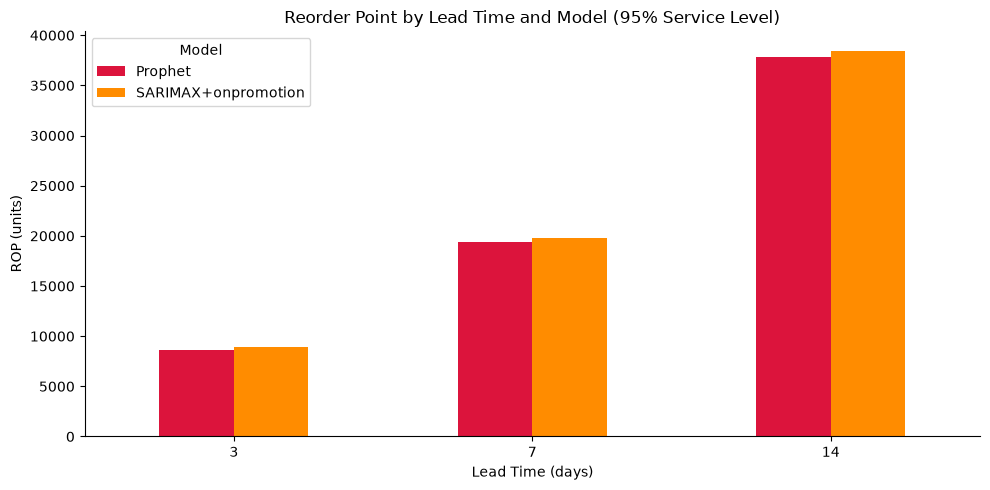

In [5]:
def reorder_point(mean_daily_demand, lead_time_days, ss):
    return mean_daily_demand * lead_time_days + ss
 
rop_rows = []
for model_label, sigma in [('Prophet', SIGMA_PROPHET), ('SARIMAX+onpromotion', SIGMA_SARIMAX)]:
    for lt in LEAD_TIMES:
        ss  = safety_stock(Z_95, sigma, lt)
        rop = reorder_point(MEAN_DAILY_DEMAND, lt, ss)
        rop_rows.append({'Model': model_label, 'Lead Time (days)': lt,
                          'Safety Stock': round(ss, 1),
                          'Expected LT Demand': round(MEAN_DAILY_DEMAND * lt, 1),
                          'ROP (units)': round(rop, 1)})
 
rop_df = pd.DataFrame(rop_rows)
print("=== Reorder Point — 95% service level ===")
print(rop_df.to_string(index=False))
 
# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
rop_pivot = rop_df.pivot(index='Lead Time (days)', columns='Model', values='ROP (units)')
rop_pivot.plot(kind='bar', ax=ax, color=['crimson', 'darkorange'], rot=0)
ax.set_title('Reorder Point by Lead Time and Model (95% Service Level)')
ax.set_ylabel('ROP (units)')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_rop_by_leadtime.png', dpi=150)
plt.show()

## 6. Economic Order Quantity (EOQ)
 
**Formula:**
 
```
EOQ = sqrt( (2 × D × S) / H )
```
 
- `D` — annual demand (Section 3)
- `S` — fixed cost per order (ordering/setup cost)
- `H` — annual holding cost per unit
 
**On S and H:** neither is observable in the Kaggle dataset — these are
business-side cost parameters, not statistical estimates. Rather than
inventing precise-looking numbers, we anchor them to commonly cited retail
grocery benchmarks and run a **sensitivity analysis** across a plausible
range, so the conclusion is a range with an explicit assumption, not a
single number dressed up as fact.
 
**Assumptions used (base case):**
- `S = $50` per order — typical for a grocery DC-to-store replenishment
  order (documented as a working assumption, not a fitted value)
- `H = 20% of unit cost annually` — standard retail holding-cost
  benchmark (storage, spoilage risk, capital cost); with an assumed
  unit cost, converted to a $/unit/year figure below

Base case: D=927,451, S=$50, H=$0.50/unit/year
EOQ (base case): 13619 units per order

=== EOQ Sensitivity — Ordering Cost x Holding Cost % ===
Ordering Cost (S) Holding Cost %   H ($/unit/yr)  EOQ (units)
              $25             10%           0.25      13619.0
              $25             20%           0.50       9630.0
              $25             30%           0.75       7863.0
              $50             10%           0.25      19261.0
              $50             20%           0.50      13619.0
              $50             30%           0.75      11120.0
             $100             10%           0.25      27239.0
             $100             20%           0.50      19261.0
             $100             30%           0.75      15726.0


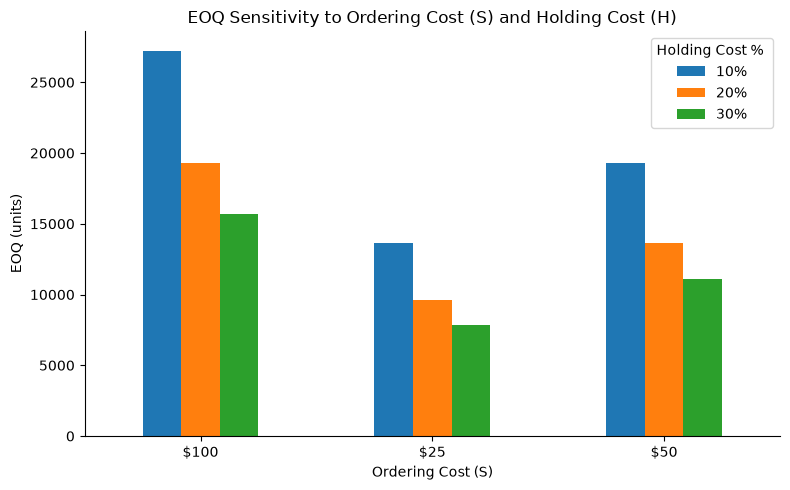


EOQ ranges from 7863 to 27239 units across the tested S/H range — order quantity is moderately sensitive to holding-cost assumptions and should be recalibrated once actual cost data is available.


In [6]:
def eoq(D, S, H):
    return np.sqrt((2 * D * S) / H)
 
# Base-case assumptions (explicitly labeled as assumptions)
ASSUMED_UNIT_COST = 2.50          # $ per unit — placeholder, grocery staple-level price
HOLDING_COST_PCT  = 0.20          # 20% of unit cost per year — retail benchmark
S_BASE = 50                       # $ per order
H_BASE = ASSUMED_UNIT_COST * HOLDING_COST_PCT   # $ per unit per year
 
eoq_base = eoq(ANNUAL_DEMAND, S_BASE, H_BASE)
print(f"Base case: D={ANNUAL_DEMAND:,.0f}, S=${S_BASE}, H=${H_BASE:.2f}/unit/year")
print(f"EOQ (base case): {eoq_base:.0f} units per order")
 
# Sensitivity: vary S and H across plausible ranges
S_range = [25, 50, 100]                                  # ordering cost scenarios
H_range = [ASSUMED_UNIT_COST * p for p in [0.10, 0.20, 0.30]]  # holding-cost % scenarios
 
sens_rows = []
for S in S_range:
    for H in H_range:
        sens_rows.append({
            'Ordering Cost (S)': f'${S}',
            'Holding Cost % ': f'{H/ASSUMED_UNIT_COST*100:.0f}%',
            'H ($/unit/yr)': round(H, 2),
            'EOQ (units)': round(eoq(ANNUAL_DEMAND, S, H), 0)
        })
 
sens_df = pd.DataFrame(sens_rows)
print("\n=== EOQ Sensitivity — Ordering Cost x Holding Cost % ===")
print(sens_df.to_string(index=False))
 
sens_pivot = sens_df.pivot(index='Ordering Cost (S)', columns='Holding Cost % ', values='EOQ (units)')
fig, ax = plt.subplots(figsize=(8, 5))
sens_pivot.plot(kind='bar', ax=ax, rot=0)
ax.set_title('EOQ Sensitivity to Ordering Cost (S) and Holding Cost (H)')
ax.set_ylabel('EOQ (units)')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_eoq_sensitivity.png', dpi=150)
plt.show()
 
print(f"\nEOQ ranges from {sens_df['EOQ (units)'].min():.0f} to {sens_df['EOQ (units)'].max():.0f} units "
      f"across the tested S/H range — order quantity is moderately sensitive to holding-cost "
      f"assumptions and should be recalibrated once actual cost data is available.")

## 7. Summary & Limitations

### Key Findings

1. **Model choice has a direct, quantifiable cost in inventory terms.**
   The Prophet vs. SARIMAX σ gap translates into materially different
   Safety Stock recommendations — this is not an academic distinction,
   it changes how much capital gets tied up in buffer inventory.
2. **Lead time is a stronger lever on inventory buffer than model choice.**
   Moving from a 3-day to a 14-day lead time increases Safety Stock and
   ROP far more than switching between Prophet and SARIMAX — supplier
   negotiation and lead-time reduction may be a higher-leverage action
   than forecast model improvement alone.
3. **EOQ is sensitive to cost assumptions that are not observable in
   this dataset** — the sensitivity table in Section 6 is reported
   instead of a single point estimate, to be honest about that
   limitation.
 
### Limitations
 
- σ is estimated from only 4 CV windows on a single store/category
  series — a genuinely robust estimate would use more windows and more
  SKUs before being used operationally.
- Lead time, ordering cost, and holding cost are illustrative
  assumptions, clearly labeled as such, not fitted or observed values.
- The i.i.d. daily-error assumption behind the √(Lead Time) scaling in
  the Safety Stock formula is a standard simplification; day-to-day
  forecast errors may be autocorrelated (see NB2's residual
  diagnostics), which would mean this formula understates true
  lead-time demand variance.
"""

In [7]:
summary = {
    'sigma_prophet': SIGMA_PROPHET,
    'sigma_sarimax': SIGMA_SARIMAX,
    'mean_daily_demand': round(MEAN_DAILY_DEMAND, 1),
    'annual_demand': round(ANNUAL_DEMAND, 0),
}
 
# 7-day lead time base case, both models
for model_label, sigma in [('prophet', SIGMA_PROPHET), ('sarimax', SIGMA_SARIMAX)]:
    ss  = safety_stock(Z_95, sigma, 7)
    rop = reorder_point(MEAN_DAILY_DEMAND, 7, ss)
    summary[f'{model_label}_safety_stock_7day'] = round(ss, 1)
    summary[f'{model_label}_rop_7day'] = round(rop, 1)
 
summary['eoq_base_case'] = round(eoq_base, 0)
 
summary_df = pd.DataFrame([summary]).T
summary_df.columns = ['Value']
print("=== NB5 Final Summary ===")
print(summary_df.to_string())
 
ss_df.to_csv(f'{SAVE_DIR}/nb5_safety_stock.csv', index=False)
rop_df.to_csv(f'{SAVE_DIR}/nb5_reorder_point.csv', index=False)
sens_df.to_csv(f'{SAVE_DIR}/nb5_eoq_sensitivity.csv', index=False)
summary_df.to_csv(f'{SAVE_DIR}/nb5_summary.csv')
 
print(f"\nSaved outputs to {SAVE_DIR}/")
print("\n=== Project Complete ===")
print("Notebooks: 01_EDA -> 02_SARIMA -> 03_Prophet -> 04_Comparison -> 05_Inventory_Optimization")
 

=== NB5 Final Summary ===
                               Value
sigma_prophet                 360.63
sigma_sarimax                 470.49
mean_daily_demand            2541.00
annual_demand              927451.00
prophet_safety_stock_7day    1569.40
prophet_rop_7day            19356.10
sarimax_safety_stock_7day    2047.50
sarimax_rop_7day            19834.20
eoq_base_case               13619.00

Saved outputs to C:/Users/Chloe/Desktop/Project/Store Sales Time series/outputs/Inventory/

=== Project Complete ===
Notebooks: 01_EDA -> 02_SARIMA -> 03_Prophet -> 04_Comparison -> 05_Inventory_Optimization
